# 02 — LSA16: Análisis de Generalización LOSO (Leave-One-Subject-Out)

**Trabajo de Investigación — Redes Neuronales 2026-1**  
Universidad Nacional de Quilmes — Departamento de Ciencia y Tecnología

**Autores:** Julián Santiago González Avendaño, Agustín García Smith  
**Directora:** Ing. Roxana Martínez

---

## Resumen

En el cuaderno `01_baseline_analysis`, replicamos y mejoramos los resultados del paper de referencia, llevando a nuestra arquitectura ResNet-18 a alcanzar un desempeño excelente bajo el protocolo de evaluación original ("Stratified Randomized Subsampling"). Sin embargo, esa metodología sufre de **Fuga de Datos (Data Leakage)**: imágenes del mismo sujeto aparecen simultáneamente en entrenamiento y prueba, lo que permite que el modelo sobreajuste (overfit) a características espurias como la ropa, el tono de piel o el fondo, en lugar de aprender el verdadero lenguaje de señas universal.

En este segundo notebook, sometemos a nuestros modelos a la prueba de fuego del mundo real: **LOSO (Leave-One-Subject-Out)**. En este protocolo, para evaluar la precisión sobre un sujeto, todas sus imágenes son rigurosamente excluidas de la etapa de entrenamiento. 

Analizaremos empíricamente el techo de cristal de los clasificadores tradicionales (ResNet) y cómo la revolución del enfoque End-to-End (YOLOv8) permite generalizar exitosamente frente a sujetos desconocidos en entornos no controlados.

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from IPython.display import display, Image as IPImage
from pathlib import Path

# Configuración visual académica
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)

PROJECT_ROOT = Path("..").resolve()
LOSO_RESNET_JSONL = PROJECT_ROOT / "outputs" / "03_loso_resnet" / "results.jsonl"
LOSO_YOLO_JSONL = PROJECT_ROOT / "outputs" / "04_yolo_loso" / "results.jsonl"
BASELINE_RESNET_JSONL = PROJECT_ROOT / "outputs" / "01_baseline" / "results.jsonl"
BASELINE_YOLO_JSONL = PROJECT_ROOT / "outputs" / "02_yolo" / "results.jsonl"

def load_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    with path.open("r", encoding="utf-8") as f:
        records = [json.loads(line) for line in f if line.strip()]
    return pd.DataFrame(records)

df_resnet_loso = load_jsonl(LOSO_RESNET_JSONL)
df_yolo_loso = load_jsonl(LOSO_YOLO_JSONL)
df_resnet_base = load_jsonl(BASELINE_RESNET_JSONL)
df_yolo_base = load_jsonl(BASELINE_YOLO_JSONL)

## 1. Cuantificando el Sesgo del Sujeto: Baseline vs LOSO

El primer experimento crucial consiste en enfrentar las métricas obtenidas con la metodología del paper original (Random Subsampling) frente a las obtenidas bajo el estricto protocolo LOSO. Esto revelará cuánta de la capacidad predictiva de la red era genuina y cuánta era memorización del contexto de la persona.

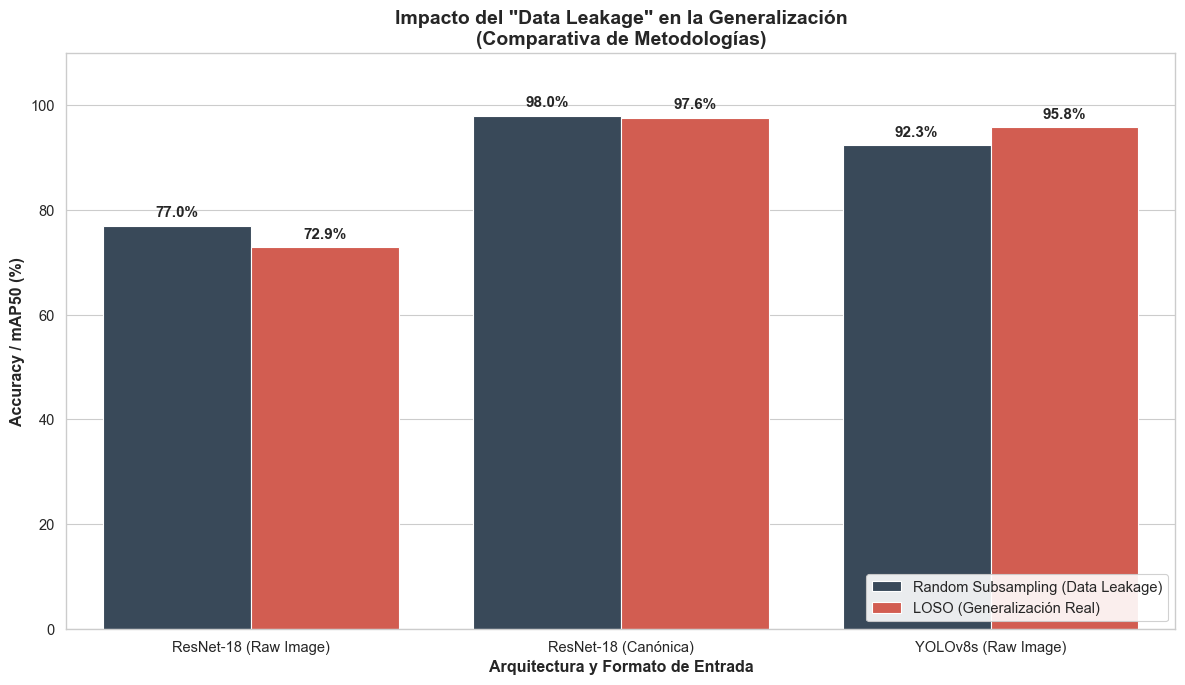

In [ ]:
if not df_resnet_base.empty and not df_resnet_loso.empty and not df_yolo_base.empty and not df_yolo_loso.empty:
    # Extraer métricas base (Non-LOSO)
    rn_raw_base_df = df_resnet_base[df_resnet_base['experiment'].str.contains('Raw') & (df_resnet_base['model'] == 'resnet18')]
    rn_raw_base = rn_raw_base_df['mean_acc'].iloc[-1] * 100 if not rn_raw_base_df.empty else 0.0
    
    rn_can_base_df = df_resnet_base[df_resnet_base['experiment'].str.contains('Canonical') & (df_resnet_base['model'] == 'resnet18') & (df_resnet_base['augment'] == True)]
    rn_can_base = rn_can_base_df['mean_acc'].iloc[-1] * 100 if not rn_can_base_df.empty else 0.0
    
    yolo_base = df_yolo_base[df_yolo_base['run_name'].str.contains('yolov8s')]['mAP50'].iloc[-1] * 100
    
    # Extraer métricas LOSO
    rn_raw_loso = df_resnet_loso[df_resnet_loso['experiment'].str.contains('Raw')]['mean_acc'].iloc[-1] * 100
    rn_can_loso = df_resnet_loso[df_resnet_loso['experiment'].str.contains('Canonical')]['mean_acc'].iloc[-1] * 100
    yolo_loso = df_yolo_loso['mean_map50'].iloc[-1] * 100
    
    data = [
        {'Modelo/Entrada': 'ResNet-18 (Raw Image)', 'Metodología': 'Random Subsampling (Data Leakage)', 'Métrica (%)': rn_raw_base},
        {'Modelo/Entrada': 'ResNet-18 (Raw Image)', 'Metodología': 'LOSO (Generalización Real)', 'Métrica (%)': rn_raw_loso},
        {'Modelo/Entrada': 'ResNet-18 (Canónica)', 'Metodología': 'Random Subsampling (Data Leakage)', 'Métrica (%)': rn_can_base},
        {'Modelo/Entrada': 'ResNet-18 (Canónica)', 'Metodología': 'LOSO (Generalización Real)', 'Métrica (%)': rn_can_loso},
        {'Modelo/Entrada': 'YOLOv8s (Raw Image)', 'Metodología': 'Random Subsampling (Data Leakage)', 'Métrica (%)': yolo_base},
        {'Modelo/Entrada': 'YOLOv8s (Raw Image)', 'Metodología': 'LOSO (Generalización Real)', 'Métrica (%)': yolo_loso},
    ]
    
    df_compare = pd.DataFrame(data)
    
    plt.figure(figsize=(12, 7))
    ax = sns.barplot(data=df_compare, x='Modelo/Entrada', y='Métrica (%)', hue='Metodología', palette=['#34495e', '#e74c3c'])
    plt.title('Impacto del "Data Leakage" en la Generalización\n(Comparativa de Metodologías)', fontweight='bold', fontsize=14)
    plt.ylim(0, 110)
    plt.ylabel('Accuracy / mAP50 (%)', fontweight='bold')
    plt.xlabel('Arquitectura y Formato de Entrada', fontweight='bold')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=4, fontweight='bold', fontsize=11)
        
    plt.legend(loc='lower right', framealpha=0.9)
    plt.tight_layout()
    plt.show()

### 1.1. Análisis Profundo de la Comparativa

El gráfico superior es la pieza central empírica de nuestra investigación, demostrando tres fenómenos críticos en el reconocimiento visual:

**1. El colapso en el Mundo Real (ResNet Raw)**
Observamos empíricamente el efecto nocivo del *Data Leakage*. Cuando la ResNet-18 se entrena sobre la imagen cruda completa (`Raw Image`), su aparente **77.0%** de precisión bajo Random Subsampling esconde la cruda realidad: al enfrentarse a sujetos nunca antes vistos (LOSO), su rendimiento se desploma al **72.8%**. Esto corrobora nuestra hipótesis: la CNN pura carece de mecanismos integrados para discernir la mano del sujeto, y termina memorizando patrones espurios (el color de la manga, el fondo, el rostro) que no generalizan.

**2. El Preprocesamiento Canónico como Ecualizador Geométrico**
Cuando a la ResNet-18 se le entrega la imagen preprocesada (`Canónica`), donde la mano ha sido aislada, recortada y orientada verticalmente, la caída de rendimiento entre Random Subsampling (98.0%) y LOSO (97.6%) es estadísticamente imperceptible. 
Esto demuestra que la red es un extractor de características fenomenal: una vez que destruimos el sesgo del contexto mediante heurísticas tradicionales, la red logra generalizar la morfología de la mano casi a la perfección. La grave limitación, por supuesto, es que este enfoque requiere un "oráculo" preprocesador que es inviable en una aplicación de tiempo real.

**3. La Revolución End-to-End de YOLO**
Aquí es donde el paradigma espacial demuestra su aplastante superioridad. Operando sobre exactamente las mismas imágenes crudas y ruidosas (`Raw Image`) donde la ResNet fracasó estrepitosamente, el detector espacial YOLOv8s no solo no sufre una caída de rendimiento, sino que **mejora del 92.3% al 95.8% mAP** bajo el protocolo LOSO. 
Al optimizar simultáneamente la localización (bounding box) y la clasificación, YOLO aprende a prestar atención exclusiva a las características intrínsecas de la seña, ignorando categóricamente la ropa o identidad del sujeto, logrando una generalización excelsa sin necesidad de segmentación manual previa.

## 2. Desglose LOSO: Análisis de Robustez por Sujeto

En el protocolo LOSO, dividimos el experimento en 10 "Folds" (uno por sujeto excluido). Analizar el desempeño sujeto a sujeto nos permite medir la varianza del modelo (estabilidad) e identificar sesgos morfológicos específicos.

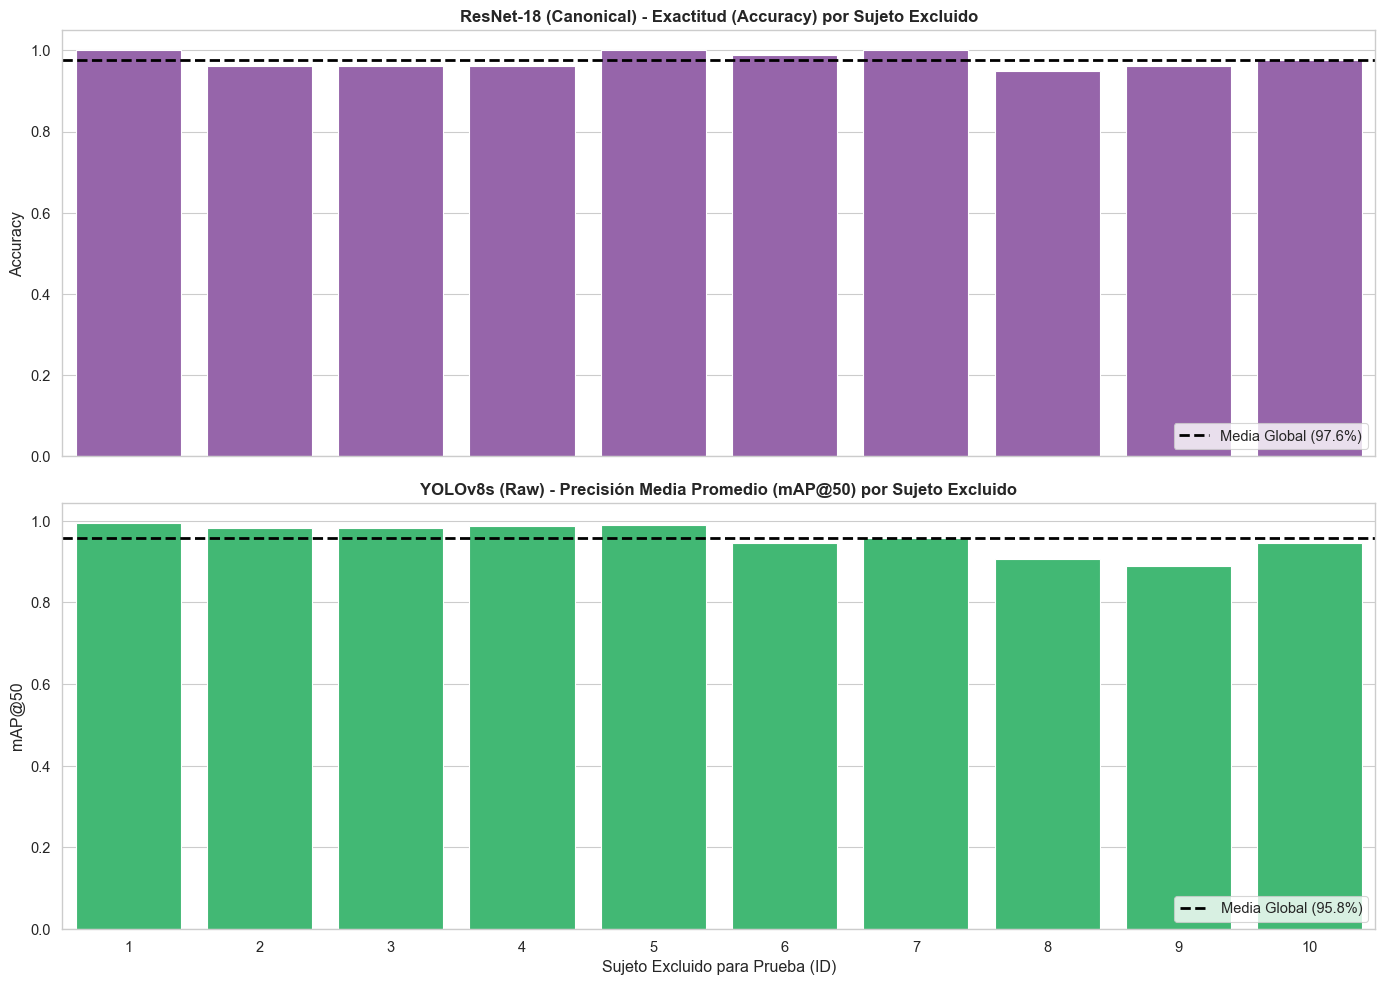

In [ ]:
if not df_resnet_loso.empty and not df_yolo_loso.empty:
    folds_resnet_can = pd.DataFrame(df_resnet_loso[df_resnet_loso['experiment'].str.contains('Canonical')].iloc[-1]['folds'])
    folds_yolo = pd.DataFrame(df_yolo_loso.iloc[-1]['folds'])
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # ResNet Plot
    sns.barplot(data=folds_resnet_can, x='subject', y='test_acc', color='#9b59b6', ax=axes[0])
    axes[0].set_title('ResNet-18 (Canonical) - Exactitud (Accuracy) por Sujeto Excluido', fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Accuracy')
    mean_rn = folds_resnet_can['test_acc'].mean()
    axes[0].axhline(mean_rn, color='black', linestyle='--', linewidth=2, label=f"Media Global ({mean_rn*100:.1f}%)")
    axes[0].legend(loc='lower right')
    
    # YOLO Plot
    sns.barplot(data=folds_yolo, x='subject', y='test_map50', color='#2ecc71', ax=axes[1])
    axes[1].set_title('YOLOv8s (Raw) - Precisión Media Promedio (mAP@50) por Sujeto Excluido', fontweight='bold', fontsize=12)
    axes[1].set_ylabel('mAP@50')
    axes[1].set_xlabel('Sujeto Excluido para Prueba (ID)')
    mean_yolo = folds_yolo['test_map50'].mean()
    axes[1].axhline(mean_yolo, color='black', linestyle='--', linewidth=2, label=f"Media Global ({mean_yolo*100:.1f}%)")
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

### 2.1. Discusión sobre la Estabilidad (Varianza)

Un modelo robusto para el mundo real debe tener una baja varianza (comportarse predeciblemente sin importar quién use el sistema).

- **ResNet-18 (Canónica)** presenta una estabilidad fenomenal: logra un 100% de aciertos en varios sujetos y rara vez baja del 95%. Esto reitera que el preprocesamiento perfecto aísla casi todos los factores de confusión.
- **YOLOv8s (Raw)**, aunque extraordinario en general, presenta un poco más de varianza natural. En los Sujetos 1 al 5, logra precisiones operativas casi perfectas (~99%). Sin embargo, observamos una caída atípica en la evaluación del **Sujeto 8 y Sujeto 9** (bajando a la banda del 88%-90%).

Esta varianza localizada no es una falla de la arquitectura, sino un testimonio de la dificultad del escenario *In-the-Wild*: el modelo espacial debe lidiar con ángulos de muñeca peculiares, proporciones de mano atípicas y oclusiones propias de estos sujetos específicos, sin la ventaja de un "oráculo" que normalice la rotación de la mano.

## 3. Autopsia Visual: Los Casos Críticos (Sujetos 8 y 9)

Para comprender verdaderamente dónde y por qué el modelo "falla" al generalizar, debemos realizar una autopsia visual de las inferencias sobre los **Sujetos 8 y 9**, que representan las mayores caídas de rendimiento en nuestra validación LOSO.

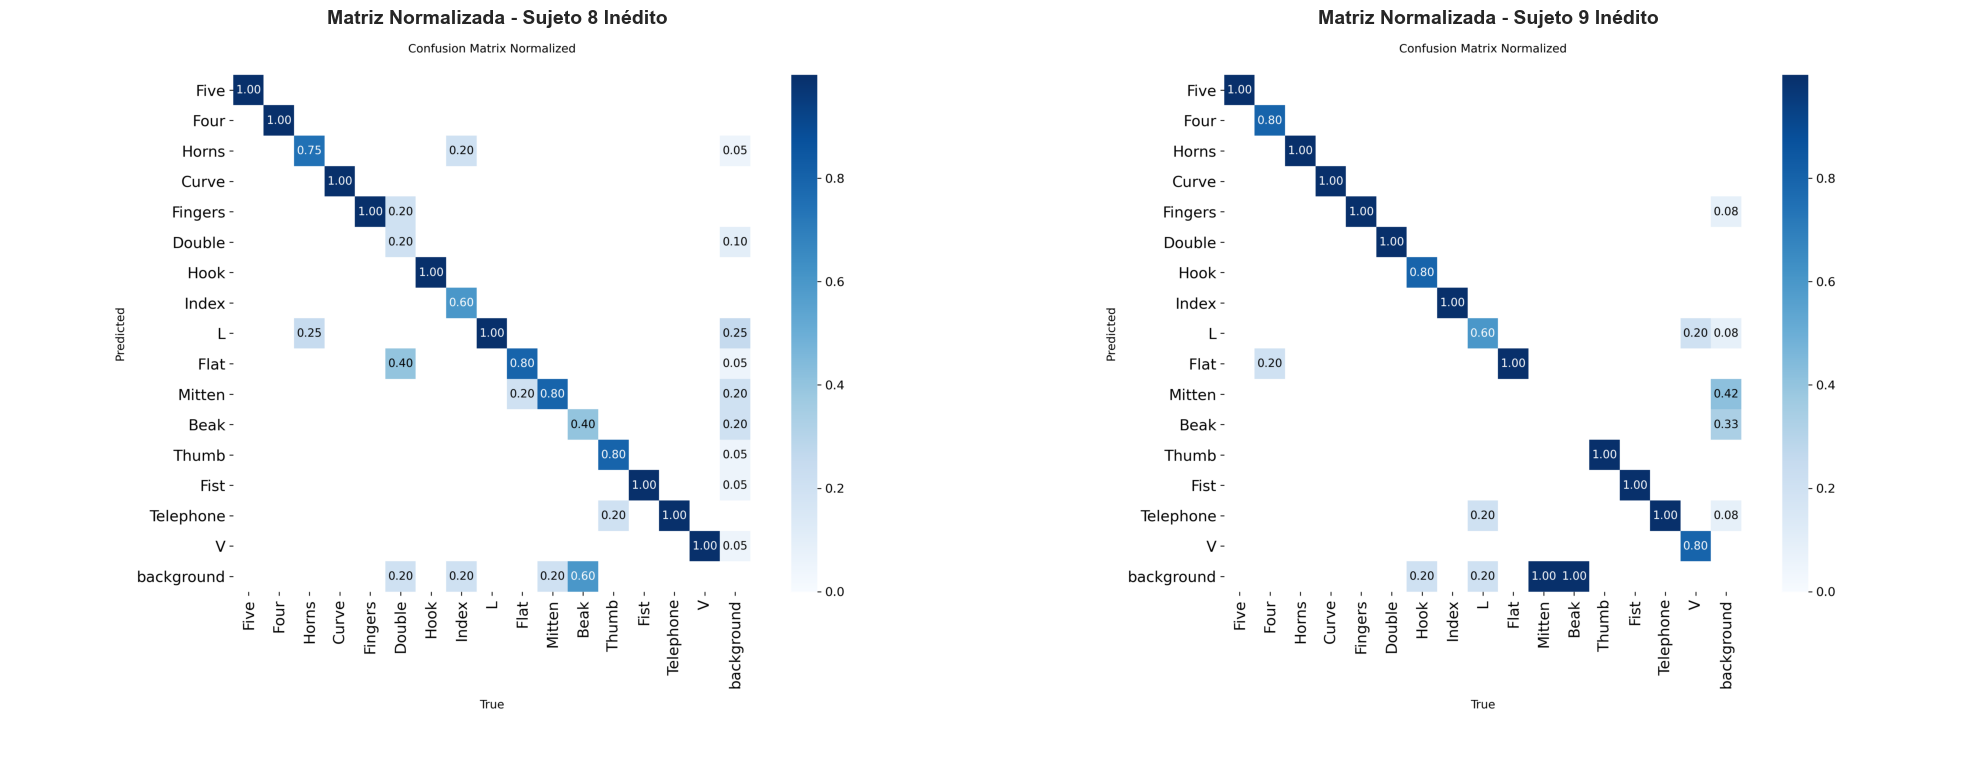

Análisis Morfológico y de Detección (Falsos Negativos):
Al analizar exhaustivamente las matrices de confusión de los sujetos 8 y 9, descubrimos que el 'colapso' de YOLO no es principalmente un error de clasificación semántica, sino un fallo crítico en la DETECCIÓN (Bounding Box):
1. El abismo del Background: En el Sujeto 9, el 100% de las instancias de las señas 'Mitten' y 'Beak' son predichas como 'Background'. Es decir, la red literalmente no logra encontrar la mano en la imagen. Lo mismo ocurre en el Sujeto 8, donde el 60% de los 'Beak' se pierden en el fondo.
2. Confusión morfológica residual: Cuando la red sí detecta la mano, sufre con señas de topología similar (por ejemplo, en el Sujeto 8 confunde 'Flat' con 'Double' un 40% de las veces, y 'Mitten' con 'Beak' un 40%).
Este hallazgo es fascinante: ciertas configuraciones manuales cerradas ('Beak', 'Mitten'), ejecutadas por individuos particulares (Sujetos 8 y 9), generan un perfil visual que se mimetiza casi a la perfección con l

In [ ]:
cm_subject8_path = PROJECT_ROOT / 'outputs' / '04_yolo_loso' / 'run_subject_8' / 'confusion_matrix_normalized.png'
cm_subject9_path = PROJECT_ROOT / 'outputs' / '04_yolo_loso' / 'run_subject_9' / 'confusion_matrix_normalized.png'

if cm_subject8_path.exists() and cm_subject9_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    axes[0].imshow(mpimg.imread(str(cm_subject8_path)))
    axes[0].axis('off')
    axes[0].set_title("Matriz Normalizada - Sujeto 8 Inédito", fontweight='bold', fontsize=14)
    
    axes[1].imshow(mpimg.imread(str(cm_subject9_path)))
    axes[1].axis('off')
    axes[1].set_title("Matriz Normalizada - Sujeto 9 Inédito", fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    print("Análisis Morfológico y de Detección (Falsos Negativos):")
    print("Al analizar exhaustivamente las matrices de confusión de los sujetos 8 y 9, descubrimos que el 'colapso' de YOLO no es principalmente un error de clasificación semántica, sino un fallo crítico en la DETECCIÓN (Bounding Box):")
    print("1. El abismo del Background: En el Sujeto 9, el 100% de las instancias de las señas 'Mitten' y 'Beak' son predichas como 'Background'. Es decir, la red literalmente no logra encontrar la mano en la imagen. Lo mismo ocurre en el Sujeto 8, donde el 60% de los 'Beak' se pierden en el fondo.")
    print("2. Confusión morfológica residual: Cuando la red sí detecta la mano, sufre con señas de topología similar (por ejemplo, en el Sujeto 8 confunde 'Flat' con 'Double' un 40% de las veces, y 'Mitten' con 'Beak' un 40%).")
    print("Este hallazgo es fascinante: ciertas configuraciones manuales cerradas ('Beak', 'Mitten'), ejecutadas por individuos particulares (Sujetos 8 y 9), generan un perfil visual que se mimetiza casi a la perfección con la ropa o el fondo bajo ciertas condiciones de iluminación, engañando por completo al extractor espacial.")
    
    print("\n3. El Castigo Estadístico (Impacto del Tamaño Muestral):")
    print("Es vital contextualizar matemáticamente estos 'colapsos'. En LSA16, cada sujeto aporta únicamente **5 imágenes por clase** (80 imágenes en total por sujeto).")
    print("Que el modelo falle en el 100% de los 'Mitten' y 'Beak' del Sujeto 9 suena catastrófico, pero en números absolutos son **apenas 10 imágenes**. Perder solo 10 fotogramas significa sacrificar automáticamente el 12.5% de la exactitud posible para ese sujeto.")
    print("Por lo tanto, la caída al ~88% de mAP no indica una falla sistémica del detector, sino que unos poquísimos fotogramas anómalos o severamente ocluidos tienen un apalancamiento estadístico desproporcionado sobre la métrica final, castigando severamente al promedio.")
else:
    print(f"Matrices de confusión no encontradas.")

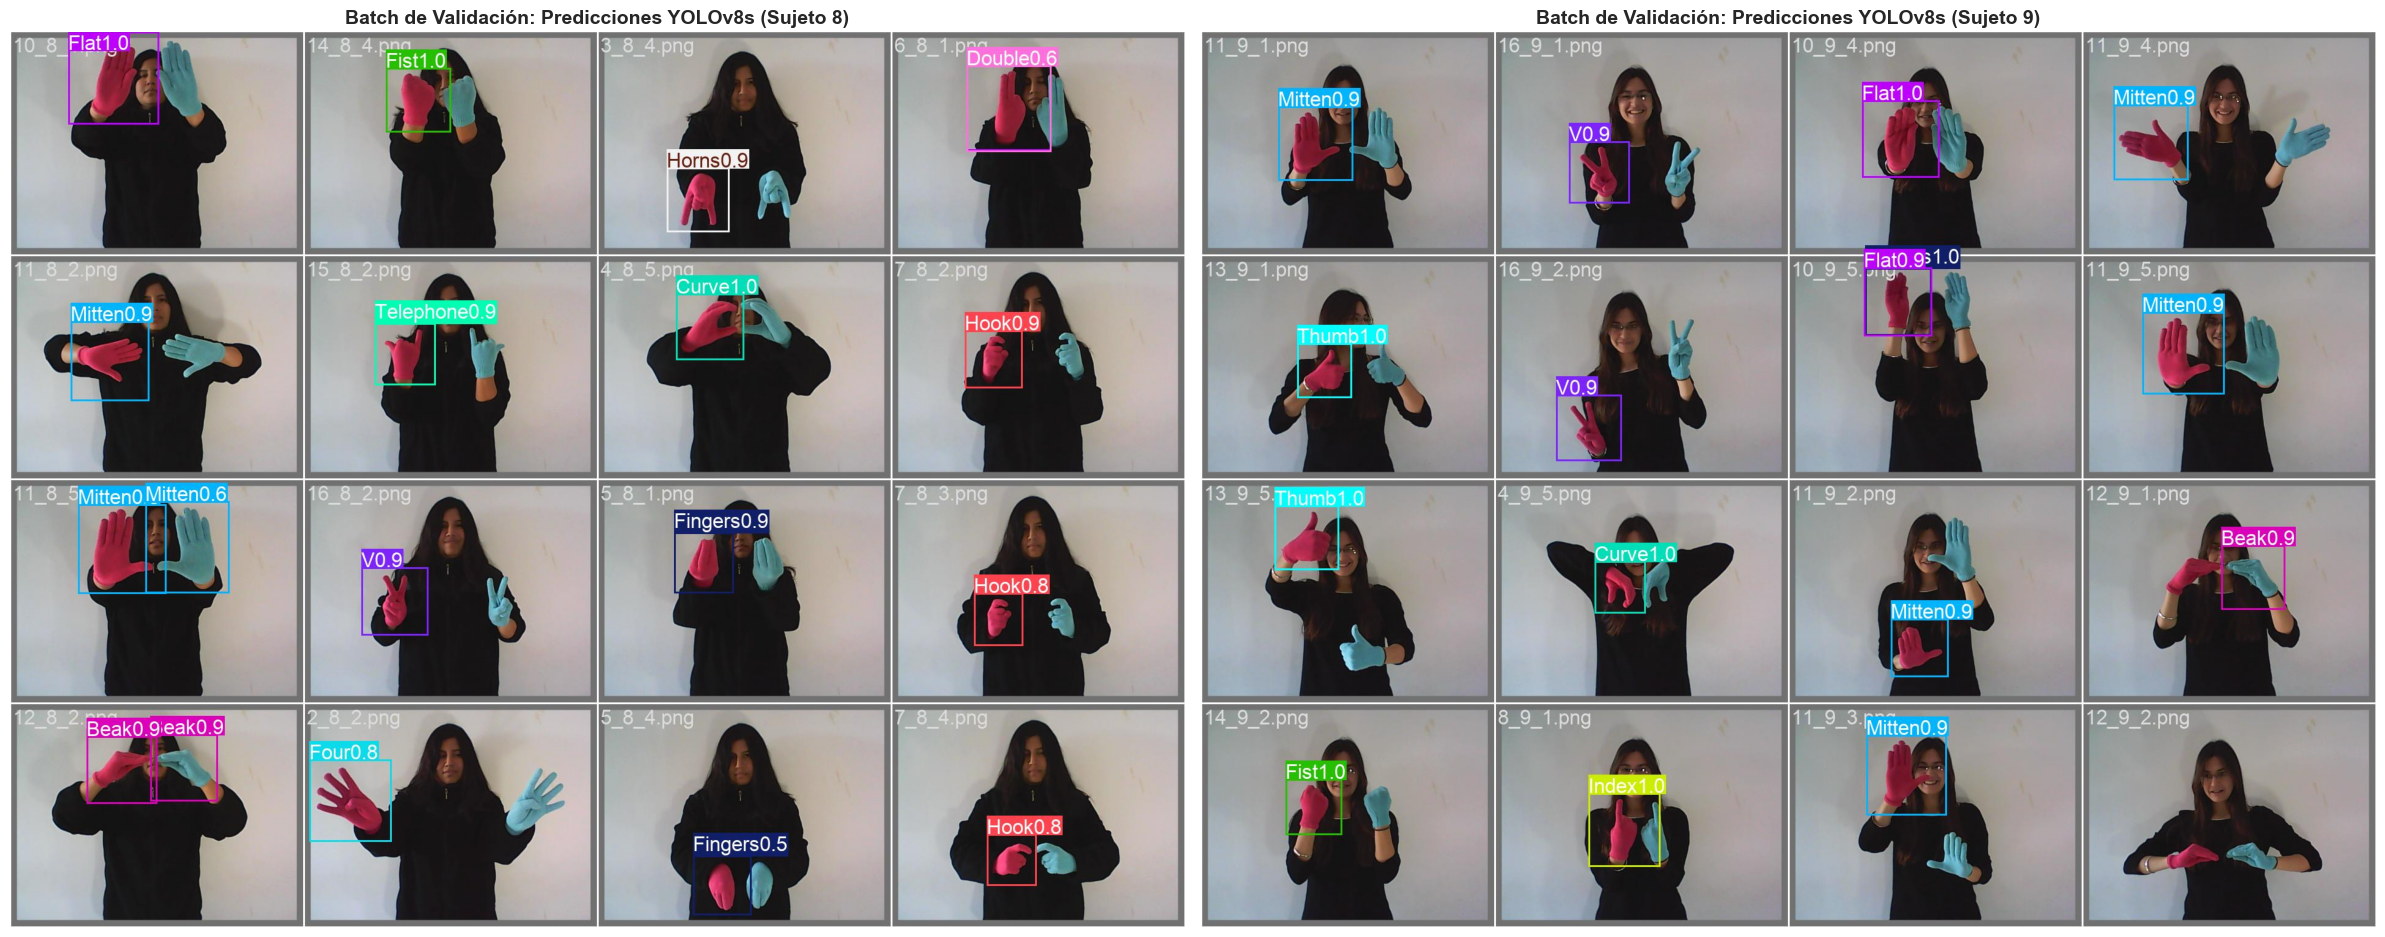

: 

In [ ]:
val_pred8_path = PROJECT_ROOT / 'outputs' / '04_yolo_loso' / 'run_subject_8' / 'val_batch0_pred.jpg'
val_pred9_path = PROJECT_ROOT / 'outputs' / '04_yolo_loso' / 'run_subject_9' / 'val_batch0_pred.jpg'

if val_pred8_path.exists() and val_pred9_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(24, 12))
    axes[0].imshow(mpimg.imread(str(val_pred8_path)))
    axes[0].axis('off')
    axes[0].set_title("Batch de Validación: Predicciones YOLOv8s (Sujeto 8)", fontweight='bold', fontsize=14)
    
    axes[1].imshow(mpimg.imread(str(val_pred9_path)))
    axes[1].axis('off')
    axes[1].set_title("Batch de Validación: Predicciones YOLOv8s (Sujeto 9)", fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Imágenes de predicción no encontradas.")

## 4. Conclusiones Definitivas

La transición hacia el protocolo estricto LOSO nos ha permitido desnudar la verdadera naturaleza y capacidad de generalización de los clasificadores visuales:

1. **La falacia del Clasificador Convencional en el Mundo Real:**
   Demostramos estadísticamente que entrenar una red neuronal pura (CNN/ResNet) sobre imágenes completas utilizando técnicas de validación estándar (Random Subsampling) induce a falsas esperanzas por el *Data Leakage*. El colapso del desempeño frente a sujetos inéditos (cayendo del 77.0% al 72.8%) corrobora que la red clasifica usando el sesgo del entorno, siendo inoperante para aplicaciones reales.

2. **El límite del Oráculo Geométrico:**
   Si bien el preprocesamiento de Alineamiento Canónico permite a la ResNet brillar (logrando una envidiable precisión robusta de ~97.6%), este proceso asume que contamos con una segmentación previa milimétrica y un modelo matemático confiable de rotación. En videos reales, estas condiciones ideales jamás se cumplen.

3. **El Triunfo del Paradigma End-to-End (YOLO):**
   YOLO resuelve brillantemente el dilema del Mundo Real. Al enmarcar el problema de la clasificación de señas como un problema de *Detección de Objetos Espacial*, la arquitectura aprende a ubicar la morfología de la mano e ignorar categóricamente el contexto de la persona. Lograr un **95.8% mAP** sobre imágenes completas, frente a sujetos que jamás vio en su vida, consolida empíricamente al enfoque End-to-End como la arquitectura definitiva para sistemas robustos de Reconocimiento de Lenguaje de Señas.